Here we will test to see if the conditional vine cdf calculated through monte carlo methods produces the correct cdf!

This will be done using a conditional gaussian distribution. 

It can be calculated that if $X$ follows a multivariate normal distribution

$$\mathbf{X} \sim \mathbf{N}(\mu, \Sigma)$$

Then the conditional distribution of a subset of $X$, given it's complement, follows a multivariate normal distribution

$$\mathbf{X}_1|\mathbf{X}_2 \sim \mathbf{N}(\mu_{1|2}, \Sigma_{1|2})$$

where

$$
\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)\\

\Sigma_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}
$$


Initial code is a tweaked version of that from https://vinecopulib.github.io/pyvinecopulib/examples/03_vine_copulas_fit_sample.html, rbp sections are entirely our own.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from src.copula import conditional_vine_copula
from src.time_varying_vine_copula import SlidingWindowDataset, rbp_process, cauchy_prior, discrete_action_prior, obs_transform_pend2, obs_transform_pendulum, action_transform_pendulum

In [39]:
def check_rbp_pdfs_real_line(prior: cauchy_prior, rbp: rbp_process, x_min=-10, x_max=10, n_points=500, dimensions = 4):
        """
        Plot each fitted RBP marginal PDF over the real line against its prior KDE.
        Useful for checking whether each marginal transformation looks sensible.
        """ 
        x_grid = np.linspace(x_min, x_max, n_points)
        iter_range = dimensions
        fig, axes = plt.subplots(1, iter_range, figsize=(4 * dimensions, 4), squeeze=False)

        prior_p, prior_c = prior.eval(np.repeat([x_grid], iter_range, axis=0).T)
        rbp_p, rbp_c = rbp.eval(prior_p, prior_c) 

        for j in range(iter_range):

            axes[0, j].plot(x_grid, prior_p[:,j], linestyle='--', alpha=0.7, label='Prior')
            axes[0, j].plot(x_grid, rbp_p[:,j], linewidth=2, label='RBP PDF')
            axes[0, j].set_title(f'Marginal {j + 1}')
            axes[0, j].set_xlabel('x')
            axes[0, j].set_ylabel('density')
            axes[0, j].legend()
            axes[0, j].grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()

In [40]:
np.random.seed(1234)  # seed for the random generator
n = 50  # number of observations
d = 4  # the dimension
mean = 1 + np.random.normal(size=d)  # mean vector
cov = np.random.normal(size=(d, d))  # covariance matrix
cov = np.dot(cov.transpose(), cov)  # make it non-negative definite
print(cov)
print(cov[1:, 1:])
print(cov[0,1:])
print(cov[1:,0])
x = np.random.multivariate_normal(mean, cov, n)
a=1
test_point = np.random.multivariate_normal(mean, cov, a)
given_cov = cov[0,0] + cov[0,1:]@np.linalg.inv(cov[1:, 1:])@cov[1:,0]
print(given_cov)
print(x.shape)

[[ 1.59271386 -2.48417931 -0.38417425 -0.15093703]
 [-2.48417931  9.98573908 -0.75938116 -3.24080217]
 [-0.38417425 -0.75938116  3.91854106 -1.45078951]
 [-0.15093703 -3.24080217 -1.45078951  3.78204036]]
[[ 9.98573908 -0.75938116 -3.24080217]
 [-0.75938116  3.91854106 -1.45078951]
 [-3.24080217 -1.45078951  3.78204036]]
[-2.48417931 -0.38417425 -0.15093703]
[-2.48417931 -0.38417425 -0.15093703]
3.0325768845525767
(50, 4)


In [41]:
rbp = rbp_process(grid_size=5000, max_rho=None)
prior = cauchy_prior()

prior.fit(x)
p, c = prior.eval(x)

rbp.fit(p, c)
p, c = rbp.eval(p, c)
print(rbp.rhos)

[0.92616702 0.99899999 0.999      0.82572709]


In [42]:
cond_vine = conditional_vine_copula(conditioning_set=[2,3,4])
cond_vine.fit_from_data(c, check_vine=True)

<pyvinecopulib.core.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types   family rotation       parameters  df   tau 
   1    1                  1, 2                             c, c Gaussian        0            -0.72 1.0 -0.52 
   1    2                  2, 4                             c, c  Clayton      270             0.85 1.0 -0.30 
   1    3                  3, 4                             c, c   Gumbel      270             1.59 1.0 -0.37 
   2    1                  1, 4                      2      c, c   Gumbel       90             1.60 1.0 -0.37 
   2    2                  2, 3                      4      c, c     Tawn      270 1.00, 0.57, 3.15 3.0 -0.44 
   3    1                  1, 3                   4, 2      c, c   Gumbel       90             1.89 1.0 -0.47 



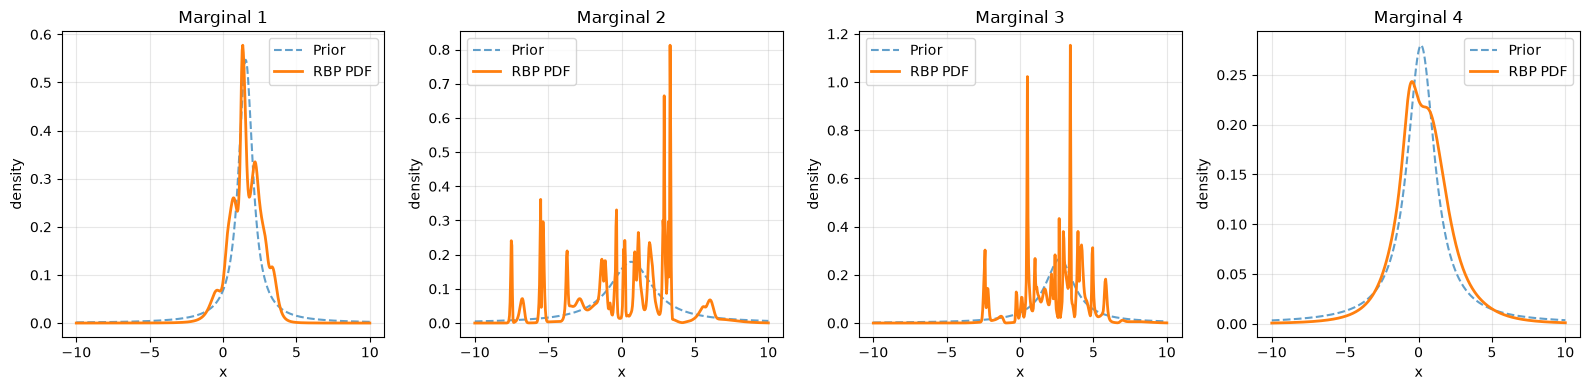

In [43]:
check_rbp_pdfs_real_line(prior, rbp)

In [44]:
x_grid = np.linspace(-2.5, 5, num =1000)

given_mean = mean[0] + cov[0,1:]@np.linalg.inv(cov[1:, 1:])@(test_point[0, 1:]-mean[1:])
given_cov = cov[0,0] - cov[0,1:]@np.linalg.inv(cov[1:, 1:])@cov[1:,0]

true_pdf = norm.pdf(x_grid, loc = given_mean, scale = given_cov)
true_cdf = norm.cdf(x_grid, loc = given_mean, scale = given_cov)

In [45]:
print(test_point)
test_p, test_c = prior.eval(test_point)
test_p, test_c = rbp.eval(test_p, test_c)

grid_p, grid_c = prior.eval(np.repeat(np.expand_dims(x_grid, 1), repeats=4, axis=1))
grid_p, grid_c = rbp.eval(grid_p, grid_c)

data = test_c
print("test_cdf shape:",data.shape)
print(data[0, 1:])
n_points = len(grid_c[:,0])
value = 1
zero_to_data = np.linspace(0, value, n_points)
numer_inputs = np.repeat([data[0]], n_points, axis=0)
print(numer_inputs.shape)
numer_inputs[:, 0] = np.where(grid_c[:,0]<0.99999, np.where(grid_c[:,0]>1e-5, grid_c[:,0], 0), 1) 

[[ 2.00239168 -0.24080077 -1.31978556  3.01638604]]
test_cdf shape: (1, 4)
[0.43675364 0.08134448 0.91063526]
(1000, 4)


In [46]:
cdf_vals = cond_vine.cdf_implicit(numer_inputs)
pdf_vals = cond_vine.pdf(numer_inputs)

In [47]:
n_samples = 1000
samples = cond_vine.conditional_sample(np.expand_dims(data[0, 1:], axis=0), n_samples=n_samples)
samples = rbp.estimate_inverse_cdf(samples)
samples = prior.ppf(samples)


(-0.04, 1.04)

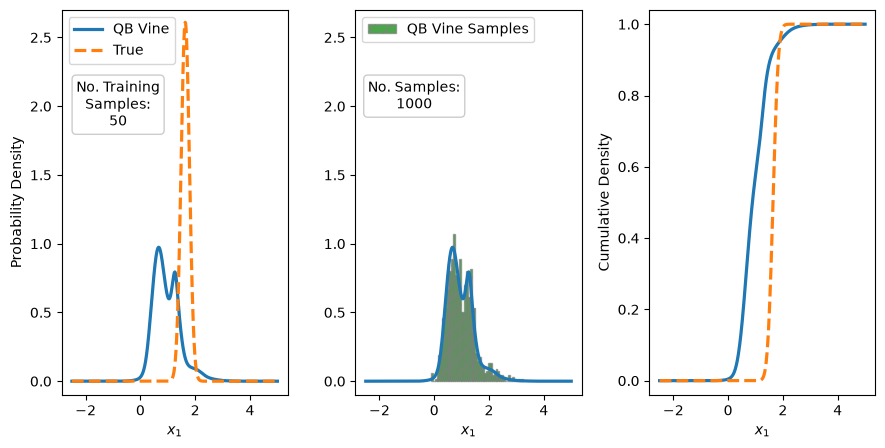

In [48]:
lw = 2.3
fig, ax = plt.subplots(1, 3, figsize=(10.5, 5))
fig.subplots_adjust(wspace=0.3)
ax[0].plot(x_grid, pdf_vals*grid_p[:,0], linewidth = lw, label = "QB Vine")
ax[0].plot(x_grid, true_pdf, linestyle="--", linewidth = lw, label = "True")
ax[0].set_ylabel("Probability Density")
ax[0].set_xlabel("$x_1$")
ax[0].text(
    0.25,
    0.82,
    f"No. Training\nSamples:\n{n}",
    transform=ax[0].transAxes,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.2),
)
ax[0].legend()
ax[0].set_ylim(-0.1, 2.7)

ax[1].plot(x_grid, pdf_vals*grid_p[:,0], linewidth = lw)
ax[1].hist(
    samples[:,0],
    bins = 50,
    density=True,
    label = "QB Vine Samples",
    hatch="//",
    edgecolor="grey",
    color = "green",
    alpha = 0.7
)
ax[1].legend(loc="upper left", alignment="left")
ax[1].text(
    0.26,
    0.82,
    f"No. Samples:\n{n_samples}",
    transform=ax[1].transAxes,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.2),
)
ax[1].set_ylim(-0.1, 2.7)
ax[1].set_xlabel("$x_1$")

ax[2].plot(x_grid, cdf_vals,  linewidth = lw, label = "QB Vine")
ax[2].plot(x_grid, true_cdf, linestyle="--",  linewidth = lw, label = "True")
ax[2].set_ylabel("Cumulative Density")
ax[2].set_xlabel("$x_1$")
ax[2].set_ylim(-0.04, 1.04)

Clean up this plot and do a plot of the sampling to show the sampling is correct.

In [49]:
# Estimated conditional density on x_grid
estimated_pdf = np.asarray(pdf_vals) * np.asarray(grid_p[:, 0])

# Ensure valid, finite densities
true_density = np.maximum(np.nan_to_num(true_pdf, nan=0.0), 0.0)
estimated_density = np.maximum(np.nan_to_num(estimated_pdf, nan=0.0), 0.0)

# Normalize over the plotted range
true_density /= np.trapz(true_density, x_grid)
estimated_density /= np.trapz(estimated_density, x_grid)

# KL divergence: D_KL(true || estimated)
epsilon = 1e-12
kl_divergence = np.trapz(
    true_density * np.log(
        (true_density + epsilon) / (estimated_density + epsilon)
    ),
    x_grid,
)

print(f"KL divergence D_KL(true || estimated): {kl_divergence:.6f}")

AttributeError: module 'numpy' has no attribute 'trapz'